<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/04_We_Do_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔧 We Do — Fine-Tuning de Modelos
### Máster de FP en Business Analytics e Inteligencia Artificial
**Módulo:** Data Analytics: Data Science, Machine Learning e Inteligencia Artificial  
**Profesores:** Daniel Toral García · Álvaro López

---

## 🤝 ¿Cómo funciona el We Do?

- ✅ **Celda ya escrita** → la ejecutamos y comentamos juntos en clase
- 🔧 **Celda con TODO** → vosotros completáis el hueco con la pista dada
- 💬 **Pregunta de clase** → debatimos la respuesta entre todos antes de seguir

---

## 🎯 Objetivo

Ya sabemos entrenar modelos. Hoy aprendemos a **mejorarlos**.

Un modelo recién entrenado es como un coche de fábrica sin ajustar: funciona, pero no está al máximo. El **fine-tuning** es la puesta a punto.

Tres pasos:
1. 🏁 Entrenar un **modelo base** y medir su accuracy
2. ⚠️ Ver qué es el **overfitting** y cómo lo detectamos
3. 🔍 Encontrar los mejores parámetros automáticamente con **GridSearch**

**Dataset:** Calidad de vinos tintos (mismo que en el I Do de Random Forest)  
**Métrica:** Accuracy — porcentaje de vinos clasificados correctamente

---
## 📦 1. Imports y Datos
✅ Ejecutad esta celda para arrancar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import accuracy_score, ConfusionMatrixDisplay, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Listo')

✅ Listo


In [2]:
# Cargamos el dataset de vinos (mismo que en el I Do de Random Forest)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df  = pd.read_csv(url, sep=';')

# Target: vino bueno (puntuación ≥ 7) = 1 | vino malo (< 7) = 0
df['vino_bueno'] = (df['quality'] >= 7).astype(int)

X = df.drop(columns=['quality', 'vino_bueno'])
y = df['vino_bueno']

# 80% para entrenar, 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'📊 {len(df)} vinos cargados — {X.shape[1]} características')
print(f'   Train: {len(X_train)} vinos | Test: {len(X_test)} vinos')

📊 1599 vinos cargados — 11 características
   Train: 1279 vinos | Test: 320 vinos


---
## 🏁 2. Modelo Base (Baseline)

El baseline es el punto de partida: entrenamos el modelo **sin tocar ningún parámetro**.  
Nos sirve de referencia para saber si el fine-tuning realmente mejora algo.

✅ Ejecutad esta celda.

In [3]:
# Modelo base con parámetros por defecto (sin afinar nada)
baseline = RandomForestClassifier(n_estimators=100, random_state=42)
baseline.fit(X_train, y_train)

# Medimos el accuracy en AMBOS conjuntos
# Esto es importante: si train y test difieren mucho → hay overfitting
acc_train_base = accuracy_score(y_train, baseline.predict(X_train))
acc_test_base  = accuracy_score(y_test,  baseline.predict(X_test))

print('📊 Accuracy del Baseline:')
print(f'   En TRAINING: {acc_train_base*100:.1f}%')
print(f'   En TEST:     {acc_test_base*100:.1f}%')
print(f'   Diferencia:  {(acc_train_base - acc_test_base)*100:.1f} puntos')

📊 Accuracy del Baseline:
   En TRAINING: 100.0%
   En TEST:     94.4%
   Diferencia:  5.6 puntos


### 💬 Pregunta de clase
El accuracy en training es mucho más alto que en test. ¿Qué creéis que significa eso?

---
## ⚠️ 3. El Overfitting — Verlo con nuestros propios ojos

**Overfitting** = el modelo memoriza los datos de entrenamiento en lugar de aprender.

> 💡 Es como un estudiante que memoriza las respuestas del examen de práctica, pero suspende el examen real porque las preguntas son diferentes.

El parámetro `max_depth` controla la complejidad del modelo:  
- Profundidad **baja** → modelo simple, puede no aprender suficiente  
- Profundidad **alta** → modelo muy complejo, tiende a memorizar

Vamos a ver esto visualmente.

✅ Ejecutad esta celda.

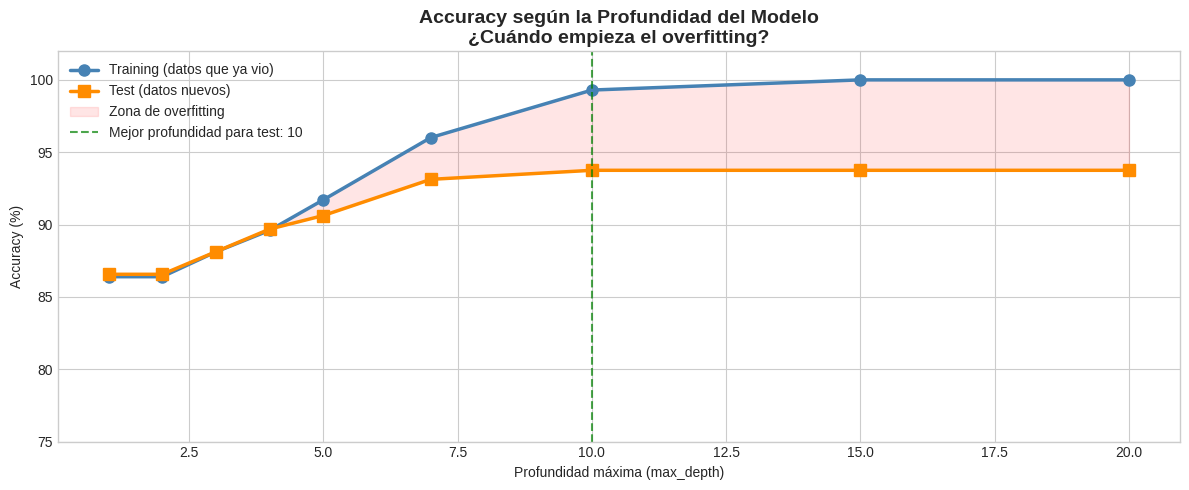

   Mejor accuracy en test: 93.8% con profundidad = 10


In [5]:
# Probamos diferentes profundidades y vemos cómo afectan al accuracy
profundidades = [1, 2, 3, 4, 5, 7, 10, 15, 20]
acc_trains, acc_tests = [], []

for depth in profundidades:
    m = RandomForestClassifier(n_estimators=50, max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc_trains.append(accuracy_score(y_train, m.predict(X_train)) * 100)
    acc_tests.append( accuracy_score(y_test,  m.predict(X_test))  * 100)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(profundidades, acc_trains, 'o-', color='steelblue',  linewidth=2.5, markersize=8, label='Training (datos que ya vio)')
ax.plot(profundidades, acc_tests,  's-', color='darkorange', linewidth=2.5, markersize=8, label='Test (datos nuevos)')
ax.fill_between(profundidades, acc_trains, acc_tests, alpha=0.1, color='red', label='Zona de overfitting')

mejor_idx = int(np.argmax(acc_tests))
ax.axvline(profundidades[mejor_idx], color='green', linestyle='--', alpha=0.7,
           label=f'Mejor profundidad para test: {profundidades[mejor_idx]}')

ax.set_title('Accuracy según la Profundidad del Modelo\n¿Cuándo empieza el overfitting?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Profundidad máxima (max_depth)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(75, 102)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'   Mejor accuracy en test: {max(acc_tests):.1f}% con profundidad = {profundidades[mejor_idx]}')

### 💬 Pregunta de clase
Mirad el gráfico. ¿A partir de qué profundidad empieza el overfitting? ¿Cómo lo sabéis?

---
## 🔍 4. GridSearch — Encontrar los Mejores Parámetros

Ya sabemos que los parámetros importan. Pero ¿cómo encontramos los mejores?  
La respuesta es **GridSearch**: probamos todas las combinaciones posibles y nos quedamos con la ganadora.

> 💡 Es como probar todas las combinaciones de ingredientes para encontrar la receta perfecta. GridSearch lo hace automáticamente.

```
Definimos qué probar:
   n_estimators : [50, 100, 200]   → 3 opciones
   max_depth    : [3, 5, 7, 10]    → 4 opciones

GridSearch prueba 3 × 4 = 12 combinaciones
y nos dice cuál da mejor accuracy.
```

✅ Ejecutad esta celda para definir el espacio de búsqueda.

In [7]:
# Definimos qué combinaciones queremos probar
# Cada lista contiene los valores candidatos para ese parámetro
param_grid = {
    'n_estimators': [50, 100, 200],     # Número de árboles
    'max_depth':    [3, 5, 7, 10],      # Profundidad máxima
    'min_samples_split': [2, 5, 10]     # Mínimo de muestras para dividir un nodo
                                        # (valores altos → modelo más conservador)
}

total = 3 * 4 * 3
print(f'🔍 GridSearch probará {total} combinaciones diferentes')
print(f'   Cada una evaluada con Cross-Validation (5 folds)')
print(f'   Total entrenamientos: {total} × 5 = {total*5}')

🔍 GridSearch probará 36 combinaciones diferentes
   Cada una evaluada con Cross-Validation (5 folds)
   Total entrenamientos: 36 × 5 = 180


### 🔧 TODO 1 — Completad el GridSearch

Tenéis que rellenar los `???` con los valores correctos. Las pistas están en los comentarios.

In [8]:
grid_search = GridSearchCV(

    # El modelo que queremos optimizar
    estimator = RandomForestClassifier(random_state=42),

    # El diccionario de combinaciones que definimos arriba
    param_grid = param_grid,

    # ¿Qué métrica usamos para elegir al ganador?
    # Pista: queremos maximizar el porcentaje de aciertos
    scoring = ???,

    # ¿En cuántos trozos dividimos los datos para evaluar?
    # Pista: el estándar es 5
    cv = ???,

    # Mostrar el progreso en pantalla (2 = detallado, 0 = silencioso)
    verbose = 2,

    # Usar todos los núcleos del procesador para ir más rápido
    # Pista: -1 significa "todos"
    n_jobs = ???
)


print('✅ GridSearch configurado — ejecutad la siguiente celda para lanzarlo')

SyntaxError: invalid syntax (109467603.py, line 11)

In [ ]:
# ✅ Lanzamos la búsqueda (puede tardar 1-2 minutos)
# Solo usa X_train — X_test lo reservamos para la evaluación final
grid_search.fit(X_train, y_train)

print('\n✅ Búsqueda completada')
print()
print('🏆 Mejores parámetros encontrados:')
for param, valor in grid_search.best_params_.items():
    print(f'   {param:<22}: {valor}')
print()
print(f'   Accuracy medio con estos parámetros: {grid_search.best_score_*100:.1f}%')

---
## 📊 5. Evaluación Final

Ahora comparamos el **baseline** con el **modelo optimizado** sobre el test set.  
Este es el momento de la verdad: ¿mereció la pena el fine-tuning?

✅ Ejecutad esta celda.

In [ ]:
# El mejor modelo ya está entrenado dentro del GridSearch
mejor_modelo = grid_search.best_estimator_

# Predicciones de ambos modelos sobre el test set
pred_base  = baseline.predict(X_test)
pred_optim = mejor_modelo.predict(X_test)

acc_base  = accuracy_score(y_test, pred_base)  * 100
acc_optim = accuracy_score(y_test, pred_optim) * 100

# Accuracy en training del modelo optimizado (para ver si el overfitting bajó)
acc_train_optim = accuracy_score(y_train, mejor_modelo.predict(X_train)) * 100

print('='*50)
print('   BASELINE vs MODELO OPTIMIZADO')
print('='*50)
print(f'   {"":22} {"Baseline":>10} {"Optimizado":>10}')
print(f'   {"-"*48}')
print(f'   {"Accuracy training":<22} {acc_train_base*100:>9.1f}% {acc_train_optim:>9.1f}%')
print(f'   {"Accuracy test":<22} {acc_base:>9.1f}% {acc_optim:>9.1f}%')
print(f'   {"Gap (train - test)":<22} {(acc_train_base*100 - acc_base):>9.1f}  {(acc_train_optim - acc_optim):>9.1f}')
print(f'   {"-"*48}')
print(f'   {"Mejora en test":<22} {"":>10} {acc_optim - acc_base:>+9.1f}%')
print('='*50)

### 🔧 TODO 2 — Visualizad las matrices de confusión

Completad el código para mostrar la matriz de confusión del **modelo optimizado**.  
La del baseline ya está hecha — seguid el mismo patrón.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz del BASELINE (ya hecha)
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, pred_base),
    display_labels=['Malo (0)', 'Bueno (1)']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Baseline\nAccuracy test: {acc_base:.1f}%', fontsize=13, fontweight='bold')

# 🔧 TODO: Completad la matriz del modelo OPTIMIZADO
# Pista: es exactamente igual que la de arriba pero usando pred_optim
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, ???),
    display_labels=['Malo (0)', 'Bueno (1)']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Modelo Optimizado\nAccuracy test: {???:.1f}%', fontsize=13, fontweight='bold')


plt.suptitle('Baseline vs Modelo Optimizado (GridSearch)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🔧 TODO 3 — Gráfico comparativo de accuracy

Completad el gráfico de barras para visualizar la mejora.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

modelos  = ['Baseline', 'Optimizado']

# 🔧 TODO: Rellenad la lista con los dos valores de accuracy en test
# Pista: usad las variables acc_base y acc_optim
valores  = [???, ???]


colores  = ['steelblue', 'darkorange']
barras   = ax.bar(modelos, valores, color=colores, edgecolor='white', width=0.4)
ax.bar_label(barras, fmt='%.1f%%', padding=5, fontsize=13, fontweight='bold')

ax.set_title('Accuracy en Test: Baseline vs Optimizado', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(80, 100)
plt.tight_layout()
plt.show()

print(f'📈 Mejora conseguida con fine-tuning: +{acc_optim - acc_base:.1f} puntos de accuracy')

---
## 🏁 6. Conclusiones

✅ Ejecutad esta celda para ver el resumen final.

In [ ]:
print('='*55)
print('  RESUMEN DEL PROCESO DE FINE-TUNING')
print('='*55)
print()
print('  PASO 1 — BASELINE')
print(f'    Accuracy en test sin afinar: {acc_base:.1f}%')
print(f'    Gap train-test:              {acc_train_base*100 - acc_base:.1f} puntos → overfitting')
print()
print('  PASO 2 — DIAGNÓSTICO DE OVERFITTING')
print('    Vimos que max_depth sin límite hace que el modelo')
print('    memorice en lugar de aprender.')
print()
print('  PASO 3 — GRIDSEARCH')
print(f'    Mejor combinación encontrada: {grid_search.best_params_}')
print()
print('  RESULTADO FINAL')
print(f'    Accuracy baseline:   {acc_base:.1f}%')
print(f'    Accuracy optimizado: {acc_optim:.1f}%')
print(f'    Mejora:              +{acc_optim - acc_base:.1f} puntos')
print(f'    Gap train-test:      {acc_train_optim - acc_optim:.1f} puntos (antes: {acc_train_base*100 - acc_base:.1f})')
print()
print('  LECCIÓN CLAVE')
print('    Entrenar un modelo es el primer paso, no el último.')
print('    Con fine-tuning conseguimos más accuracy Y menos overfitting.')
print('    GridSearch hace el trabajo sucio por nosotros.')
print('='*55)

### 💬 Pregunta final de clase

GridSearch probó 36 combinaciones. ¿Siempre merece la pena probar tantas?  
¿Qué haríais si tuvierais 10 parámetros con 5 valores cada uno?

---
## 📌 Resumen de lo que hemos aprendido

| Concepto | En una frase |
|---|---|
| **Baseline** | El punto de partida sin afinar. Sin él no sabemos si mejoramos. |
| **Overfitting** | El modelo memoriza en lugar de aprender. Training alto, test bajo. |
| **Hiperparámetros** | Los "botones" del modelo que nosotros configuramos (`max_depth`, `n_estimators`...). |
| **GridSearch** | Prueba todas las combinaciones de hiperparámetros y devuelve la mejor. |
| **Cross-Validation** | Evalúa el modelo varias veces con diferentes divisiones de datos para tener un resultado más fiable. |